#Install Libraries

In [457]:
%pip install scikit-learn pandas numpy matplotlib seaborn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [458]:
#libraries
import pandas as pd
import numpy as np

#visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#preprocessing and preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer  
from sklearn.pipeline import Pipeline

#Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

#Evaluation
from sklearn.metrics import (accuracy_score, precision_score,recall_score, f1_score,  roc_auc_score, roc_curve, confusion_matrix,classification_report
)


#Saving/loading models
import joblib

#Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

print("libraries imported successfully")

libraries imported successfully


#Load Dataset


In [459]:
#Load dataset
df=pd.read_csv(r"C:\Users\nkemn\OneDrive\Desktop\Customer_churn\WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("shape:", df.shape)
df.head()

shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [460]:
counts_citizen=df['SeniorCitizen'].value_counts()
print("Senior Citizen counts:\n", counts_citizen)

Senior Citizen counts:
 SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64



## 3 Exploratory Data Analysis (EDA)


In [461]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [462]:
df.describe(include= 'number').T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [463]:
print('Dataset shape:', df.shape)
print("\ncolumn data types:\n", df.dtypes)

Dataset shape: (7043, 21)

column data types:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


#Change monthly charges, total charges to integer 

In [464]:

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [465]:
print('Dataset shape:', df.shape)
print("\ncolumn data types:\n", df.dtypes)

Dataset shape: (7043, 21)

column data types:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [466]:
# Unique value counts for categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_columns:
    print(f"--- {col} ({df[col].nunique()} unique values) ---")
    print(df[col].value_counts().head())  # Display top 10 unique values
    print()

--- customerID (7043 unique values) ---
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
Name: count, dtype: int64

--- gender (2 unique values) ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Partner (2 unique values) ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents (2 unique values) ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService (2 unique values) ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines (3 unique values) ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService (3 unique values) ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity (3 unique values) ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: cou

In [467]:
#Method 2: #manually list the categorical columns i want to analyse
categorical_columns = ['Gender', 'SeniorCitizen', 'Contract', 'PaymentMethod', 'InternetService', 'OnlineSecurity', 
'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines', 'Partner', 'Dependents']

for col in categorical_columns:
    if col in df.columns:
        print(f"--- {col} ({df[col].nunique()} unique values) ---")
        print(df[col].value_counts().head(10))
        print()

--- SeniorCitizen (2 unique values) ---
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

--- Contract (3 unique values) ---
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

--- PaymentMethod (4 unique values) ---
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

--- InternetService (3 unique values) ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity (3 unique values) ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- OnlineBackup (3 unique values) ---
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

--- DeviceProtection (3 unique values) ---
DeviceProtection
No     

In [468]:
# Target variable distribution
target_col = "Churn"
print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True) * 100)


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


### 3.1 Target class balance

The target is imbalanced (roughly 74% of 'customers didnt canceled their services' , while  ` 27% cancelled their services`), which we'll keep in mind during evaluation
(accuracy alone can be misleading — we'll rely on precision, recall, F1, and ROC-AUC as well).


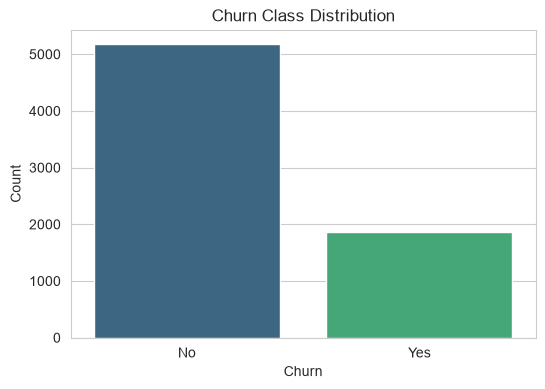

In [469]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target_col, palette="viridis")
plt.title("Churn Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()


In [470]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## 4. Data Visualization

# Distribution of numerical features
num_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

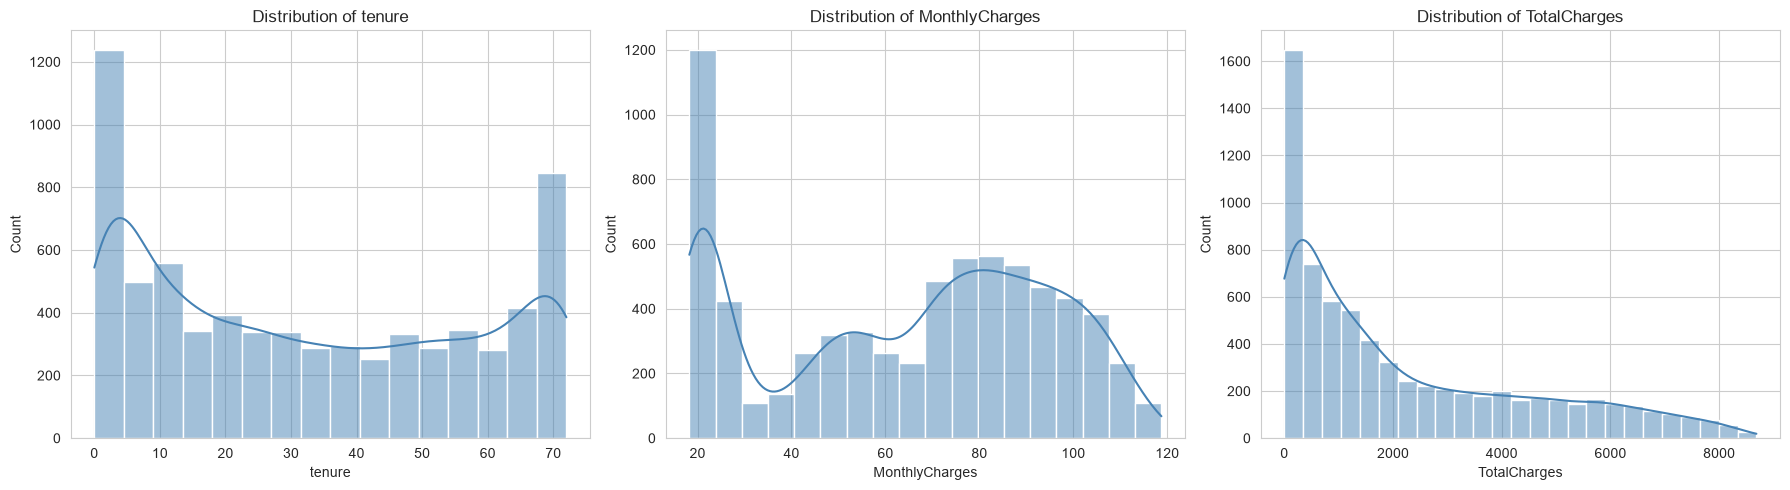

In [471]:
# Distribution of numerical features
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


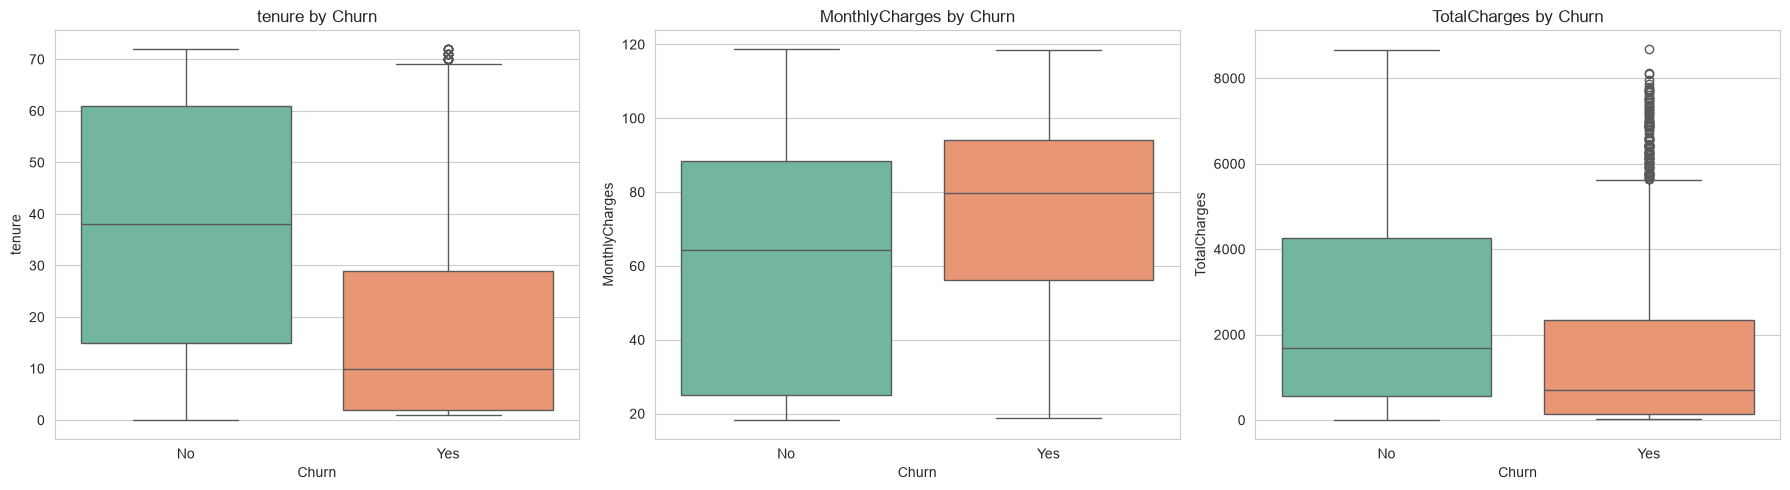

In [472]:
# Numerical features vs income
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=target_col, y=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} by Churn")
plt.tight_layout()
plt.show()


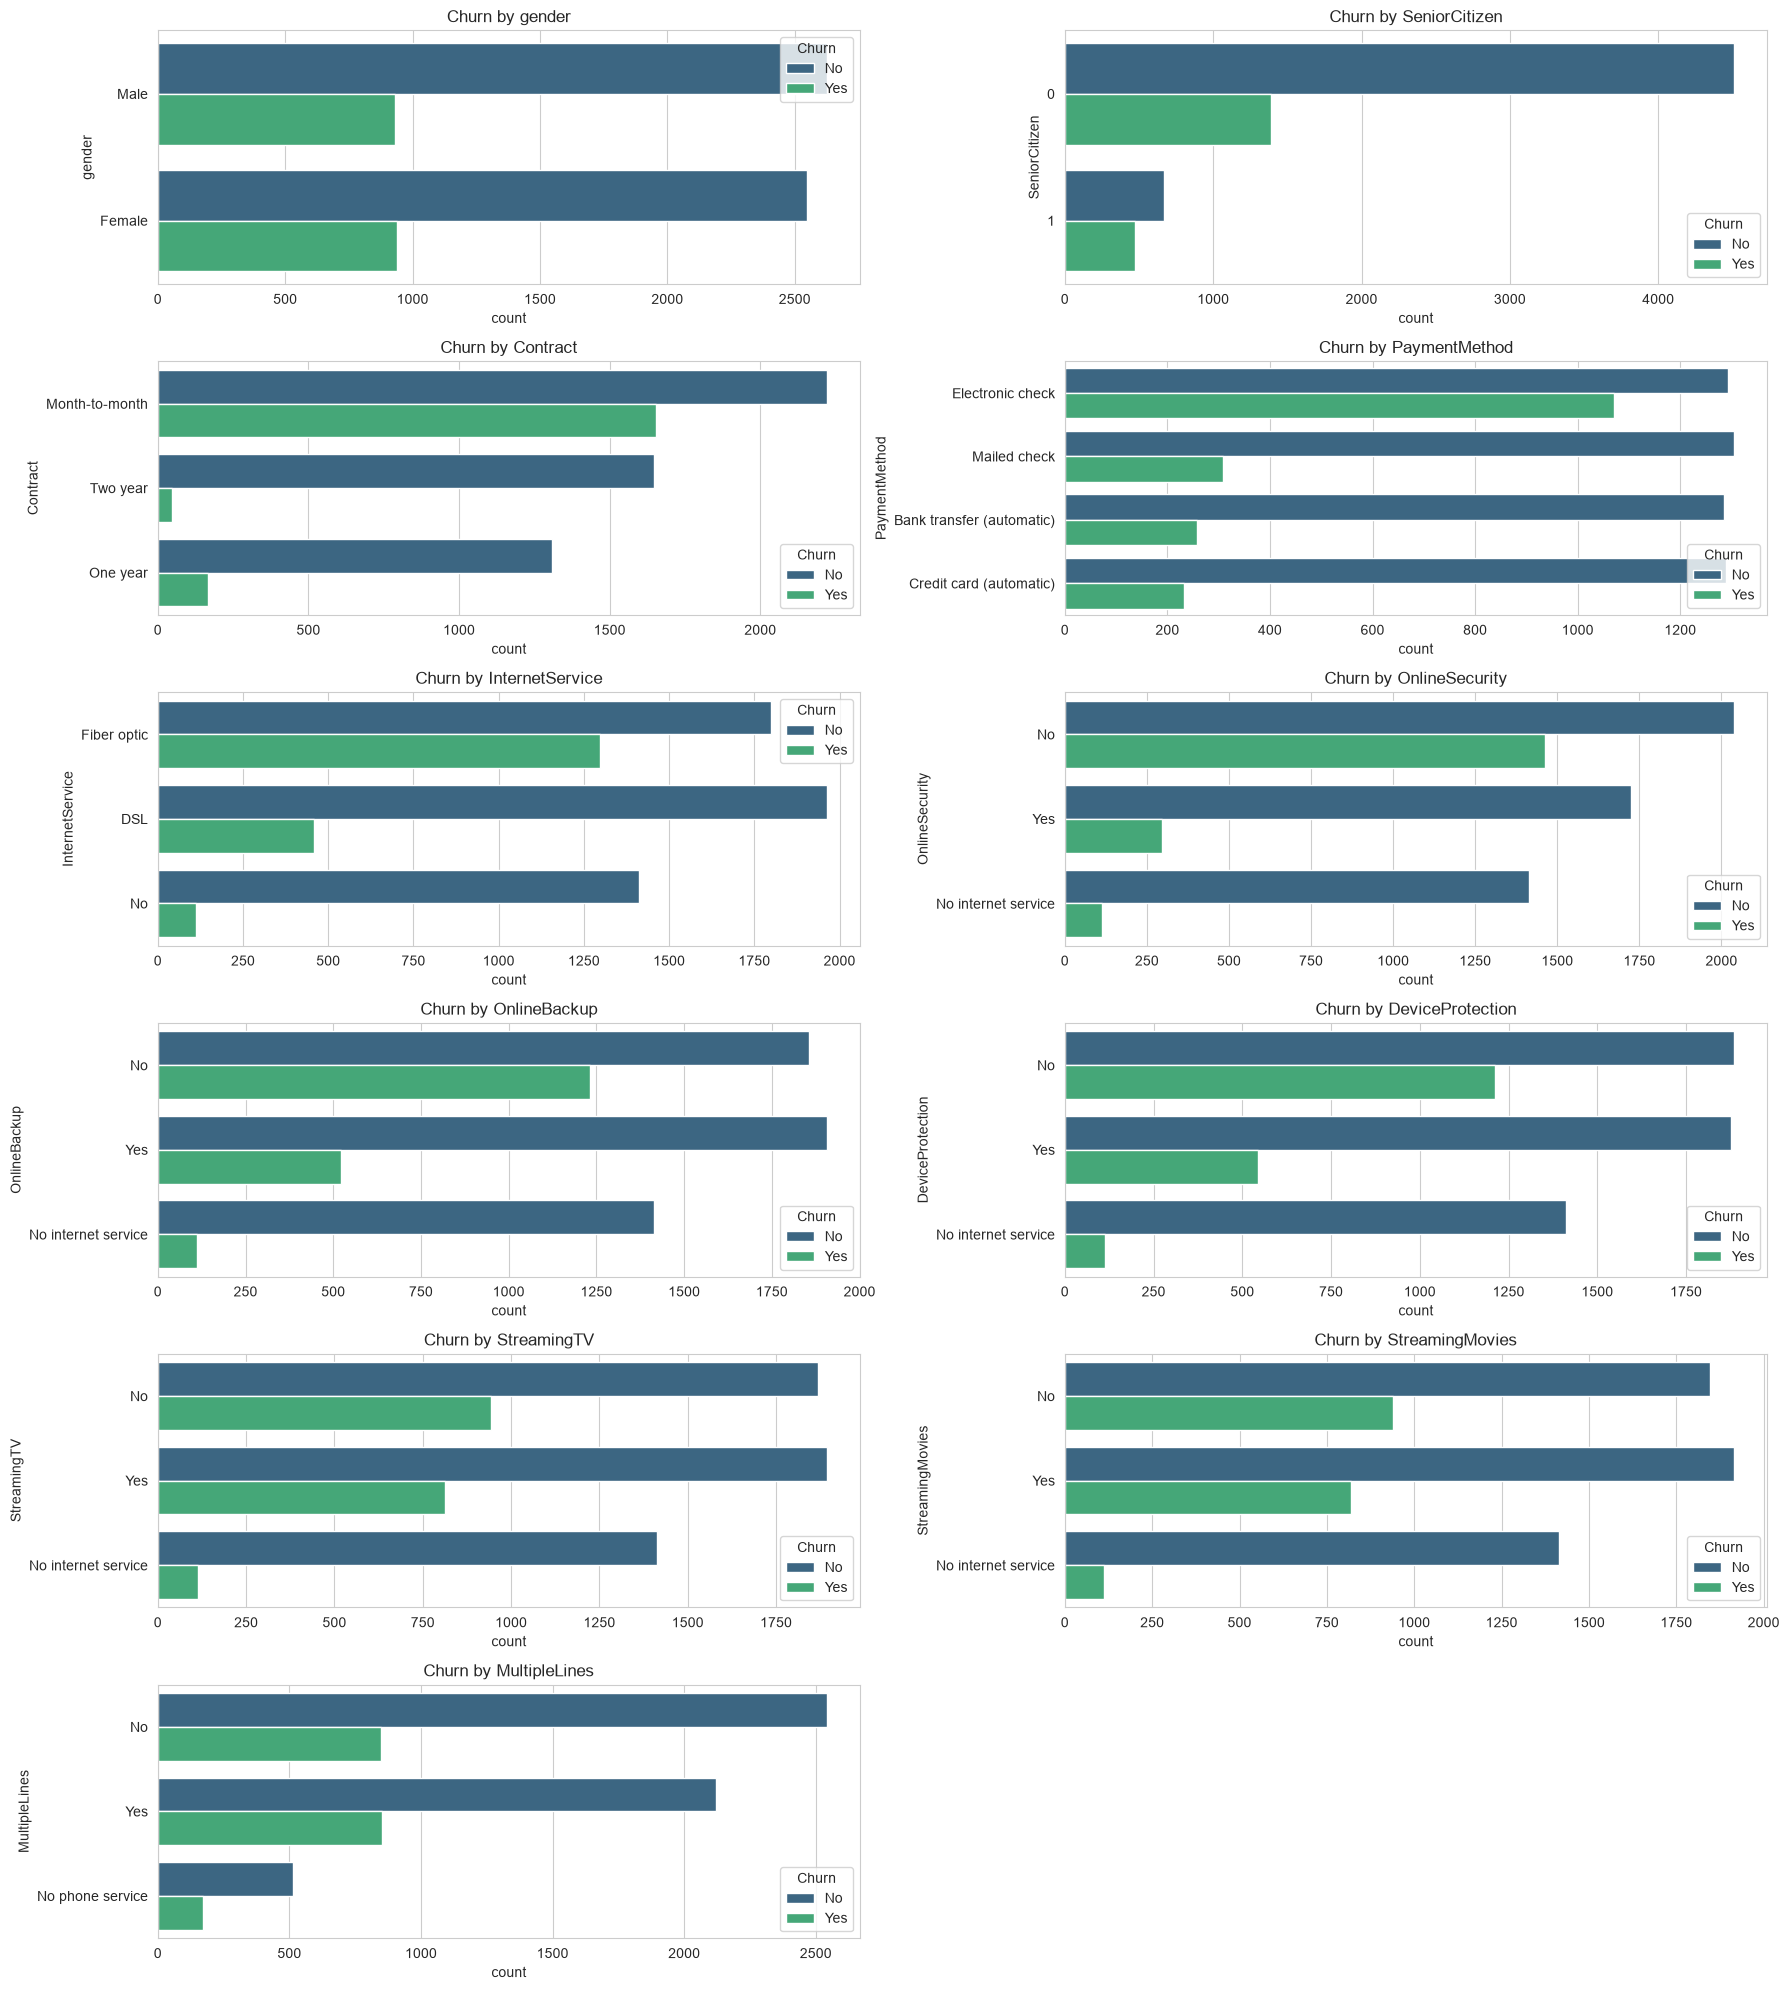

In [473]:

# Key categorical features vs churn
cat_features_to_plot = ['gender', 'SeniorCitizen', 'Contract', 'PaymentMethod', 'InternetService', 'OnlineSecurity', 
'OnlineBackup', 'DeviceProtection', 'StreamingTV', 'StreamingMovies', 'MultipleLines', ]

# Change 3 rows to 4 rows (6 x 2 = 8 subplots total)
fig, axes = plt.subplots(6, 2, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(cat_features_to_plot):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, hue=target_col, order=order, ax=axes[i], palette="viridis")
    axes[i].set_title(f"Churn by {col}")

# Hide any remaining unused subplots
for j in range(len(cat_features_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

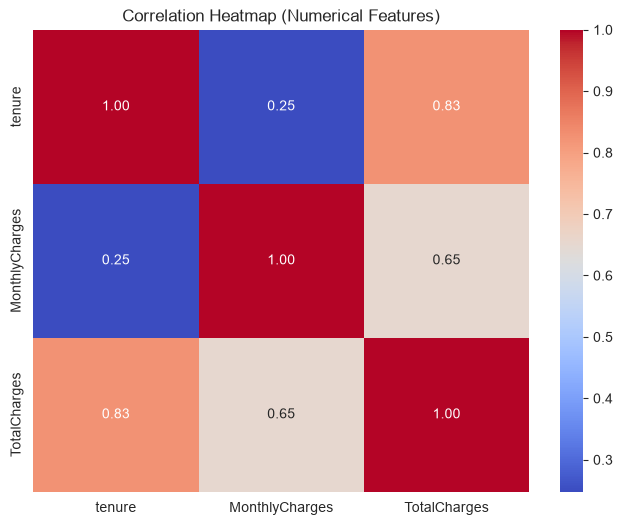

In [474]:
# Correlation heatmap for numerical features
plt.figure(figsize=(8, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()


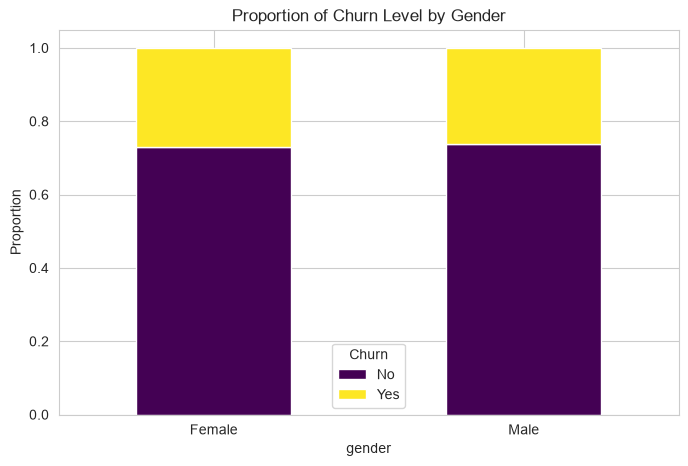

In [475]:
# Sex distribution across churn(proportional)
pd.crosstab(df['gender'], df['Churn'], normalize='index').plot(kind='bar', stacked=True, colormap='viridis')
plt.title("Proportion of Churn Level by Gender")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()


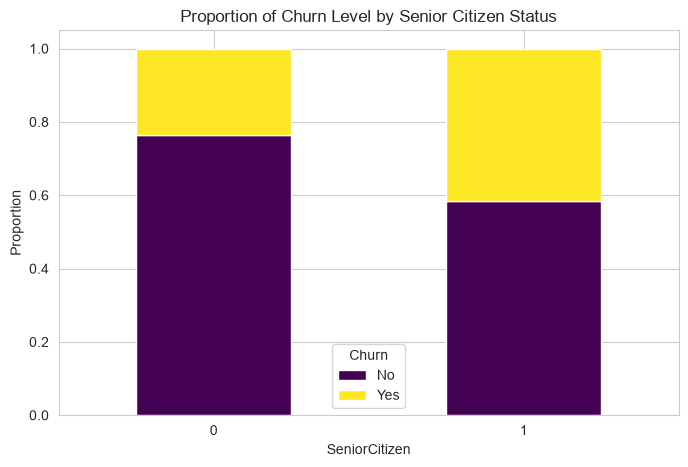

In [476]:
# SeniorCitizen distribution across churn(proportional)
pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index').plot(kind='bar', stacked=True, colormap='viridis')
plt.title("Proportion of Churn Level by Senior Citizen Status")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

## 5. Handling Missing Values

There are no missing values in this dataset.

In [477]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [478]:
# Replace '?' (with possible surrounding whitespace) with NaN
df = df.replace(r'^\s*\?\s*$', np.nan, regex=True)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] >= 0].sort_values("missing_count", ascending=False)
missing_summary


,missing_count,missing_pct
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


## 6. Detecting and Removing Duplicates

In [479]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

if num_duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicate rows found.")


Number of duplicate rows: 0
No duplicate rows found.


## 7. Outlier Detection
We use the IQR (Interquartile Range) method to detect outliers in key numerical columns.
`totalcahrges` is naturally very skewed (most values are 0 with a few large values), and `tenure is a bit skewed
so rather than blindly removing outliers there, we cap extreme values to reduce their influence while
keeping the signal that "some capital gain/loss" often correlates with higher income.


In [480]:
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return len(outliers), lower, upper

outlier_check_cols = ["TotalCharges", "tenure"]
for col in outlier_check_cols:
    count, lower, upper = detect_outliers_iqr(df, col)
    print(f"{col}: {count} outliers (bounds: [{lower:.2f}, {upper:.2f}])")


TotalCharges: 0 outliers (bounds: [-4683.52, 8868.67])
tenure: 0 outliers (bounds: [-60.00, 124.00])


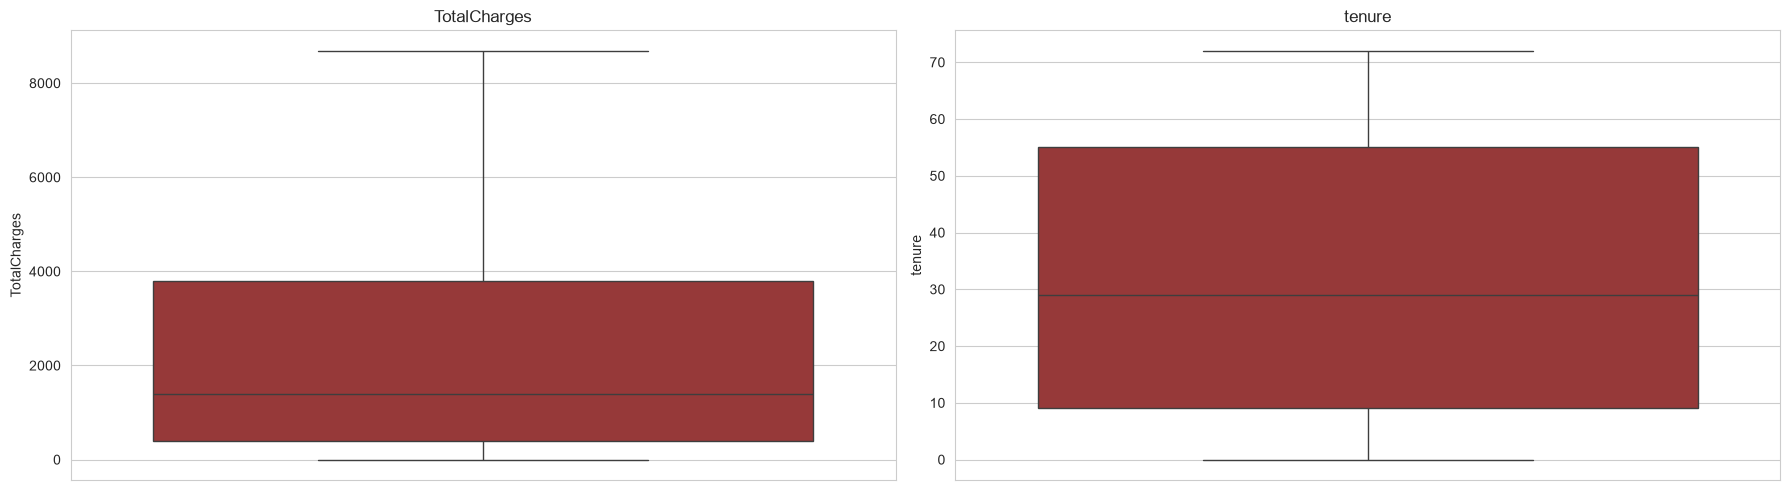

In [481]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Limit loop to only the first 2 columns in the list
for i, col in enumerate(outlier_check_cols[:2]):
    sns.boxplot(y=df[col], ax=axes[i], color="brown")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [482]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


## 8. Feature Engineering

In [483]:
# 1. Clean data types
#if 'customerID' in df.columns:
 #   df.drop('customerID', axis=1, inplace=True)

# 2. Target & Binary encoding
df['Churn'] = df['Churn'].astype(str).str.strip().replace({'Yes': 1, 'No': 0})

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip().replace({'Yes': 1, 'No': 0})

# 3. Simplify 'No service' responses safely
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

existing_service_cols = [c for c in service_cols if c in df.columns]

if existing_service_cols:
    df[existing_service_cols] = df[existing_service_cols].replace({
        'No internet service': 'No', 
        'No phone service': 'No'
    })

# 4. Service count & ratio features
df['total_services'] = (df[existing_service_cols] == 'Yes').sum(axis=1)


# 5. Contract & Payment flags
df['is_auto_payment'] = df['PaymentMethod'].str.contains('automatic').astype(int)
df['tenure_group'] = pd.cut(df['tenure'], bins=[-1, 12, 24, 48, 72], 
                            labels=['New', 'Short-term', 'Long-term', 'Loyal'])

# 6. One-hot encode remaining categorical variables
categorical_cols = ['gender', 'InternetService', 'Contract', 'PaymentMethod', 'tenure_group'] + service_cols
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)



In [484]:
print("New engineered features:")

# Unpack the list variable using * and fix column typos
columns_to_show = ["TotalCharges", "Churn", "is_auto_payment", "total_services"]

df[columns_to_show].head()

New engineered features:


,TotalCharges,Churn,is_auto_payment,total_services
0,29.85,0,0,1
1,1889.50,0,0,2
2,108.15,1,0,2
3,1840.75,0,1,3
4,151.65,1,0,0


In [485]:
#drop some columns
#customer_id,partner, dependents

In [486]:
df = df.drop(columns=[col for col in ["customerID", "Partner", "Dependents"] if col in df.columns])
df.head()

,SeniorCitizen,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,total_services,is_auto_payment,gender_Male,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_Short-term,tenure_group_Long-term,tenure_group_Loyal,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,MultipleLines_Yes
0,0,1,No,Yes,29.85,29.85,0,1,0,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False
1,0,34,Yes,No,56.95,1889.50,0,2,0,True,False,False,True,False,False,False,True,False,True,False,True,False,True,False,False,False,False
2,0,2,Yes,Yes,53.85,108.15,1,2,0,True,False,False,False,False,False,False,True,False,False,False,True,True,False,False,False,False,False
3,0,45,No,No,42.30,1840.75,0,3,1,True,False,False,True,False,False,False,False,False,True,False,True,False,True,True,False,False,False
4,0,2,Yes,Yes,70.70,151.65,1,0,0,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False


## 9. Encoding Categorical Variables


Target('churn) (binary:0=no, 1=yes)
 **Categorical features** → One-Hot Encoding (via `ColumnTransformer`, applied inside the modeling pipeline
  so it's fit only on the training data and saved together with the model — this avoids data leakage).


In [487]:
from sklearn.preprocessing import LabelEncoder

# 1. Ensure correct column name capitalization ('Churn' vs 'churn')
target_col = "Churn" if "Churn" in df.columns else "churn"

# 2. Label-encode the target column
label_encoder = LabelEncoder()
df["churn_encoded"] = label_encoder.fit_transform(df[target_col])

# Print clean label mapping (e.g., {'No': 0, 'Yes': 1})
mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print("Label mapping:", mapping)

# 3. Separate features (X) and target (y)
X = df.drop(columns=[target_col, "churn_encoded"])
y = df["churn_encoded"]

# 4. Correctly capture ALL categorical and numerical features
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()  # Captures all int/float types

print("\nCategorical features:", categorical_features)
print("Numerical features:", numerical_features)

Label mapping: {0: 0, 1: 1}

Categorical features: ['PhoneService', 'PaperlessBilling']
Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'total_services', 'is_auto_payment']


## 10. Feature Scaling (via Preprocessing Pipeline)

We combine **One-Hot Encoding** (categorical) and **Standard Scaling** (numerical) into a single
`ColumnTransformer`. This preprocessor is placed inside each model's `Pipeline`, so scaling/encoding
is always fit on training data only and applied consistently at prediction time — including after
we reload the saved model.


In [488]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features)
    ]
)

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 11. Train/Test Split

In [489]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTraining target distribution:\n", y_train.value_counts(normalize=True))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True))


Training set: (5634, 26)
Test set: (1409, 26)

Training target distribution:
 churn_encoded
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test target distribution:
 churn_encoded
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## 12. Training Multiple Algorithms

We train five classifiers, each wrapped in a `Pipeline` with the shared preprocessing step:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)


In [490]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42)
}

pipelines = {}
baseline_results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })
    print(f"Trained: {name}")

baseline_df = pd.DataFrame(baseline_results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
baseline_df


Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest
Trained: KNN
Trained: SVM


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.799148,0.658537,0.505348,0.571861,0.832594
1,KNN,0.770759,0.579439,0.497326,0.535252,0.769375
2,SVM,0.788502,0.655738,0.427807,0.517799,0.792570
3,Random Forest,0.763662,0.572438,0.433155,0.493151,0.784558
4,Decision Tree,0.711143,0.456693,0.465241,0.460927,0.638228


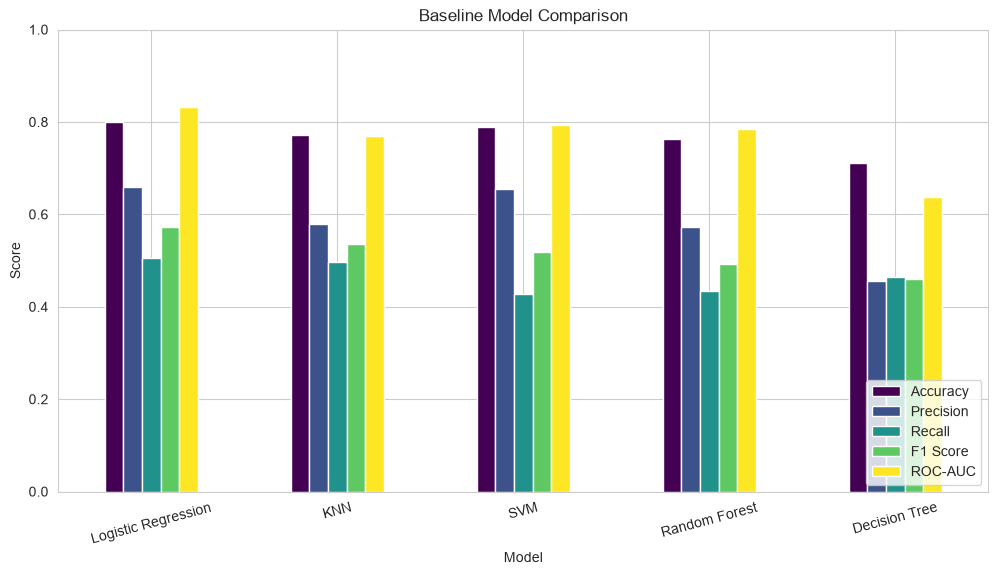

In [491]:
baseline_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(
    kind="bar", figsize=(12, 6), colormap="viridis"
)
plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

## 13. Hyperparameter Tuning with GridSearchCV

We tune each model's key hyperparameters using 5-fold cross-validation, optimizing for **F1 score**
(a good balance for the moderately imbalanced target). Grids are kept modest in size so the notebook
runs in a reasonable amount of time — feel free to expand them for a more thorough search.


In [492]:
param_grids = {
    "Logistic Regression": {
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__solver": ["liblinear", "lbfgs"]
    },
    "Decision Tree": {
        "classifier__max_depth": [5, 10, 15, None],
        "classifier__min_samples_split": [2, 5, 10]
    },
    "Random Forest": {
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [10, 20, None],
        "classifier__min_samples_split": [2, 5]
    },
    "KNN": {
        "classifier__n_neighbors": [5, 11, 21],
        "classifier__weights": ["uniform", "distance"]
    },
    "SVM": {
        "classifier__C": [0.1, 1, 10],
        "classifier__kernel": ["rbf", "linear"]
    }
}

best_estimators = {}
tuned_results = []

for name, model in models.items():
    print(f"Tuning {name} ...")
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    grid = GridSearchCV(
        pipe,
        param_grid=param_grids[name],
        scoring="f1",
        cv=5,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    best_estimators[name] = grid.best_estimator_

    y_pred = grid.best_estimator_.predict(X_test)
    y_proba = grid.best_estimator_.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })
    print(f"  Best params: {grid.best_params_}")
    print(f"  Best CV F1: {grid.best_score_:.4f}\n")

tuned_df = pd.DataFrame(tuned_results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
tuned_df


Tuning Logistic Regression ...
  Best params: {'classifier__C': 10, 'classifier__solver': 'liblinear'}
  Best CV F1: 0.5702

Tuning Decision Tree ...
  Best params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 10}
  Best CV F1: 0.5016

Tuning Random Forest ...
  Best params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
  Best CV F1: 0.5404

Tuning KNN ...
  Best params: {'classifier__n_neighbors': 21, 'classifier__weights': 'uniform'}
  Best CV F1: 0.5446

Tuning SVM ...
  Best params: {'classifier__C': 1, 'classifier__kernel': 'linear'}
  Best CV F1: 0.5702



,Model,Best Params,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM,"{'classifier__C': 1, 'classifier__kernel': 'li...",0.794180,0.634615,0.529412,0.577259,0.827559
1,Logistic Regression,"{'classifier__C': 10, 'classifier__solver': 'l...",0.799858,0.658621,0.510695,0.575301,0.832651
2,Random Forest,"{'classifier__max_depth': 10, 'classifier__min...",0.786373,0.632727,0.465241,0.536210,0.828965
3,KNN,"{'classifier__n_neighbors': 21, 'classifier__w...",0.781405,0.616197,0.467914,0.531915,0.813999
4,Decision Tree,"{'classifier__max_depth': 10, 'classifier__min...",0.755855,0.544118,0.494652,0.518207,0.741661


## 14. Model Evaluation

Detailed evaluation of the tuned models: confusion matrices, classification reports, and ROC curves.


In [493]:
tuned_df[["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]]


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM,0.794180,0.634615,0.529412,0.577259,0.827559
1,Logistic Regression,0.799858,0.658621,0.510695,0.575301,0.832651
2,Random Forest,0.786373,0.632727,0.465241,0.536210,0.828965
3,KNN,0.781405,0.616197,0.467914,0.531915,0.813999
4,Decision Tree,0.755855,0.544118,0.494652,0.518207,0.741661


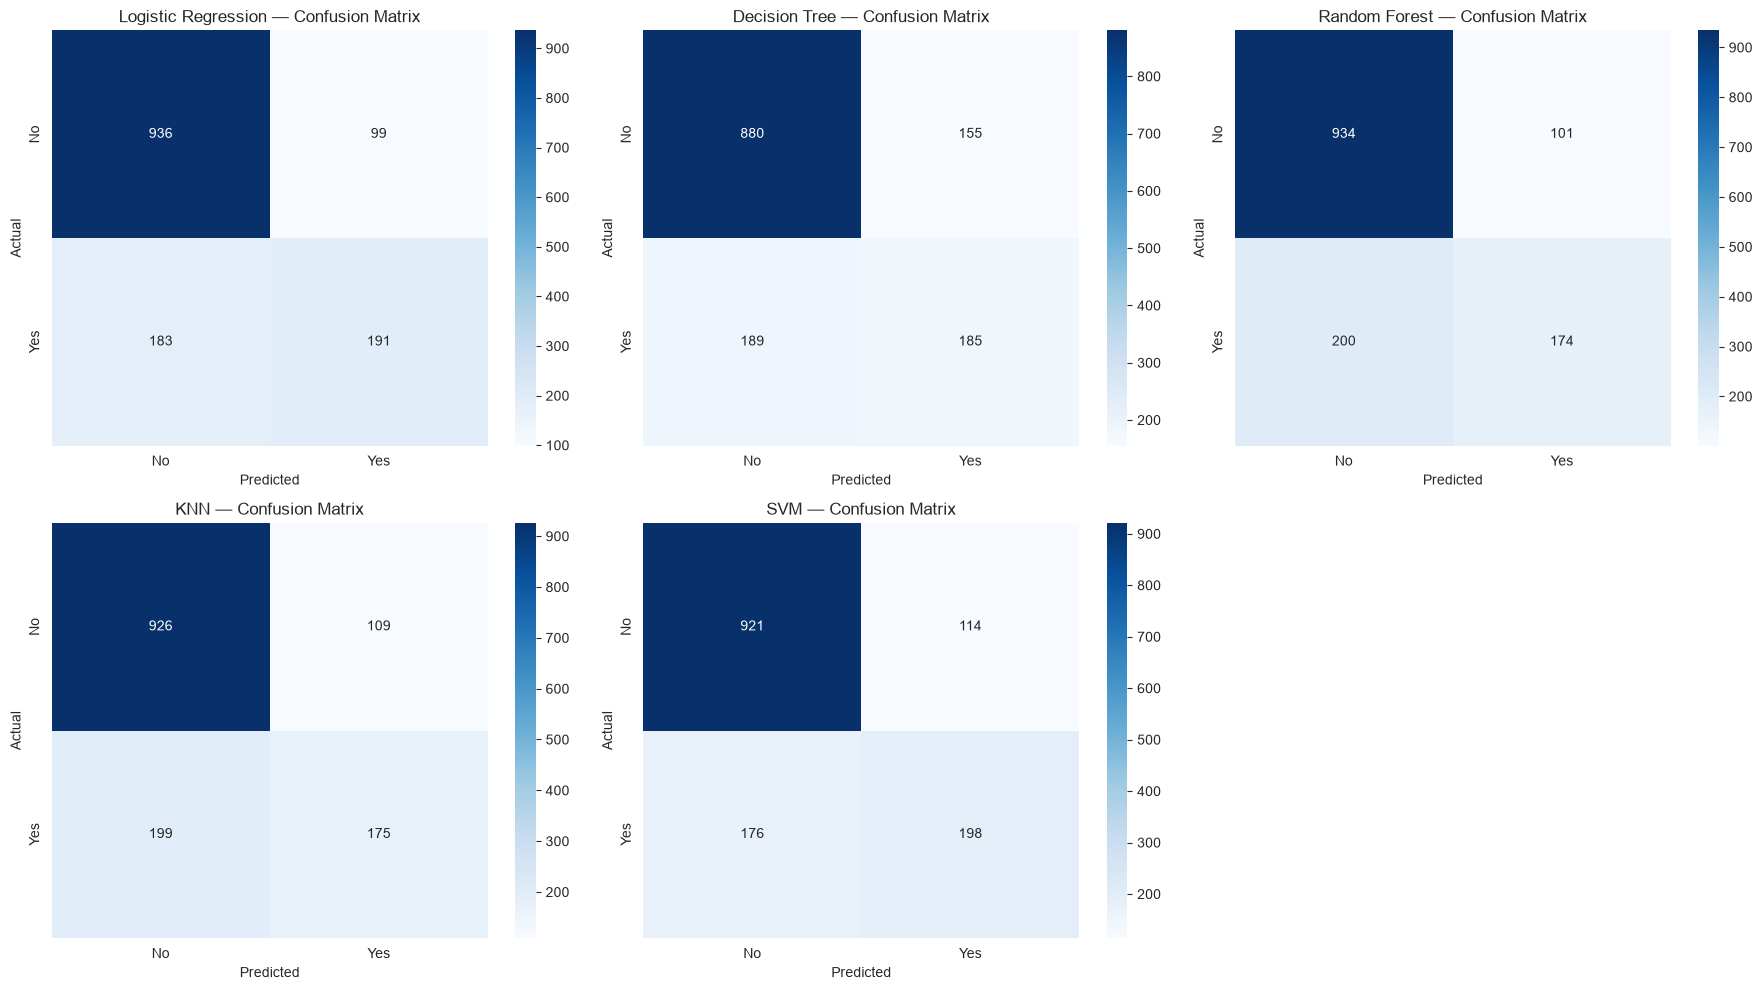

In [494]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, est) in enumerate(best_estimators.items()):
    y_pred = est.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    axes[i].set_title(f"{name} — Confusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# hide unused subplot
for j in range(len(best_estimators), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [495]:
for name, est in best_estimators.items():
    y_pred = est.predict(X_test)
    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))
    print()


===== Logistic Regression =====
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.66      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


===== Decision Tree =====
              precision    recall  f1-score   support

          No       0.82      0.85      0.84      1035
         Yes       0.54      0.49      0.52       374

    accuracy                           0.76      1409
   macro avg       0.68      0.67      0.68      1409
weighted avg       0.75      0.76      0.75      1409


===== Random Forest =====
              precision    recall  f1-score   support

          No       0.82      0.90      0.86      1035
         Yes       0.63      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.7

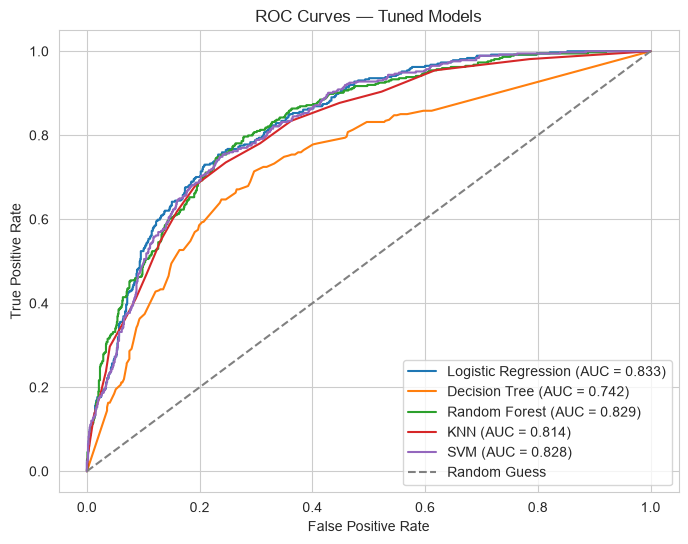

In [496]:
# ROC Curves for all tuned models
plt.figure(figsize=(8, 6))
for name, est in best_estimators.items():
    y_proba = est.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Tuned Models")
plt.legend(loc="lower right")
plt.show()


In [497]:
# Select the best overall model based on F1 score (change this rule if you prefer to optimize for
# a different metric, e.g. ROC-AUC or recall)
best_model_name = tuned_df.iloc[0]["Model"]
best_model = best_estimators[best_model_name]
print(f"Best model selected: {best_model_name}")
print(tuned_df.iloc[0])


Best model selected: SVM
Model                                                        SVM
Best Params    {'classifier__C': 1, 'classifier__kernel': 'li...
Accuracy                                                 0.79418
Precision                                               0.634615
Recall                                                  0.529412
F1 Score                                                0.577259
ROC-AUC                                                 0.827559
Name: 0, dtype: object


## 15. Feature Importance

We extract feature importances from a tree-based model (Random Forest / Decision Tree), since these
provide interpretable, built-in importance scores. If the selected best model doesn't natively support
feature importances (e.g. KNN, SVM with rbf kernel), we fall back to displaying the Random Forest's
importances for interpretability purposes.


In [498]:
def get_feature_names(preprocessor_fitted, numerical_features, categorical_features):
    ohe = preprocessor_fitted.named_transformers_["cat"]
    ohe_feature_names = ohe.get_feature_names_out(categorical_features)
    return list(numerical_features) + list(ohe_feature_names)

# 1. Extract the fitted preprocessor step from your Random Forest pipeline
rf_pipeline = best_estimators["Random Forest"]
rf_model = rf_pipeline.named_steps["classifier"]
fitted_preprocessor = rf_pipeline.named_steps["preprocessor"]

# 2. Extract feature names directly from the fitted preprocessor
feature_names = fitted_preprocessor.get_feature_names_out()

# 3. Create the importance DataFrame
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

# Strip prefixes like 'num__' or 'cat__'
importance_df["feature"] = importance_df["feature"].str.replace(r"^(num|cat)__", "", regex=True)

# Sort and display
importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)
importance_df.head(20)


,feature,importance
0,MonthlyCharges,0.283426
1,tenure,0.265737
2,TotalCharges,0.242906
3,total_services,0.071680
4,PaperlessBilling_Yes,0.048857
5,is_auto_payment,0.046081
6,SeniorCitizen,0.029926
7,PhoneService_Yes,0.011388


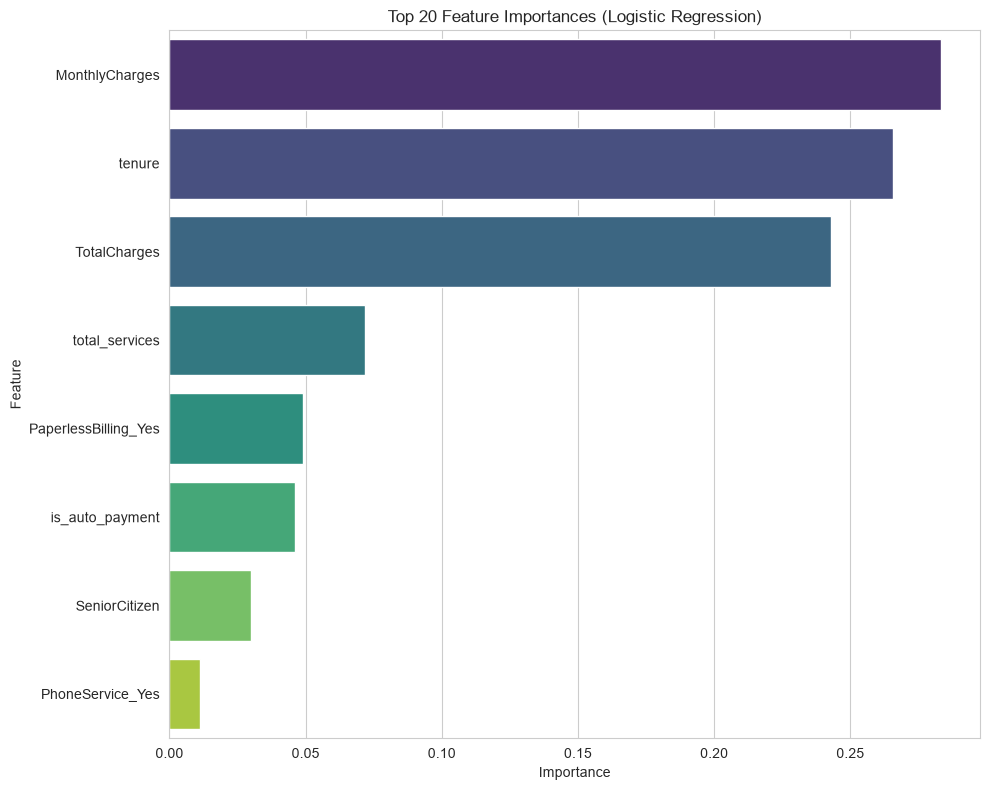

In [499]:
plt.figure(figsize=(10, 8))
top_n = 20
sns.barplot(data=importance_df.head(top_n), x="importance", y="feature", palette="viridis")
plt.title(f"Top {top_n} Feature Importances (Logistic Regression)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [500]:
import os

os.makedirs("saved_models", exist_ok=True)

MODEL_PATH = f"saved_models/best_model_{best_model_name.lower().replace(' ', '_')}.joblib"
LABEL_ENCODER_PATH = "saved_models/label_encoder.joblib"

joblib.dump(best_model, MODEL_PATH)
joblib.dump(label_encoder, LABEL_ENCODER_PATH)

print(f"Best model ('{best_model_name}') saved to: {MODEL_PATH}")
print(f"Label encoder saved to: {LABEL_ENCODER_PATH}")


Best model ('SVM') saved to: saved_models/best_model_svm.joblib
Label encoder saved to: saved_models/label_encoder.joblib


In [501]:
# Load the saved pipeline and label encoder
loaded_model = joblib.load(MODEL_PATH)
loaded_label_encoder = joblib.load(LABEL_ENCODER_PATH)

print("Model and label encoder loaded successfully.")
print(type(loaded_model))


Model and label encoder loaded successfully.
<class 'sklearn.pipeline.Pipeline'>


In [502]:
# 1. Take a sample of 5 rows from your test set (simulating new customers)
sample = X_test.sample(5, random_state=1)

# 2. Generate predictions and probability of churning
predictions = loaded_model.predict(sample)
probabilities = loaded_model.predict_proba(sample)[:, 1]  # Index 1 = Probability of Churning (Yes / 1)

# 3. Create a results DataFrame
results = sample.copy()

# 4. Map numerical predictions (0 / 1) back to text ('No' / 'Yes')
results["predicted_churn"] = loaded_label_encoder.inverse_transform(predictions)
results["churn_probability"] = probabilities.round(3)

# 5. Display key customer features alongside the prediction and risk score
display_columns = [
    "tenure", 
    "Contract", 
    "MonthlyCharges", 
    "InternetService", 
    "predicted_churn", 
    "churn_probability"
]

# Print only the columns present in your DataFrame
available_cols = [col for col in display_columns if col in results.columns]
results[available_cols]

,tenure,MonthlyCharges,predicted_churn,churn_probability
126,27,78.05,1,0.532
4017,28,59.00,0,0.119
5860,2,70.00,1,0.540
4114,51,19.95,0,0.028
3790,2,19.30,0,0.089


In [503]:
def predict_customer_churn(customer_dict, model, encoder=None):
    df_single = pd.DataFrame([customer_dict])
    
    pred = model.predict(df_single)[0]
    prob = model.predict_proba(df_single)[0][1]
    
    label = encoder.inverse_transform([pred])[0] if encoder else ("Yes" if pred == 1 else "No")
    
    print(f"Predicted Churn Label: {label}")
    print(f"Churn Probability: {prob:.2%}")
    print(f"Risk Assessment: {'🔴 High Risk' if prob >= 0.50 else '🟢 Low Risk'}")
   

# Example Run:
single_test_profile = {
    "gender": "Male", "SeniorCitizen": 0, "Partner": "No", "Dependents": "No",
    "tenure": 1, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "No",
    "StreamingMovies": "No", "Contract": "Month-to-month", "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check", "MonthlyCharges": 70.35, "TotalCharges": 70.35,
    "total_services": 0, "is_auto_payment": 0, "tenure_group": "New", "avg_monthly_charges": 70.35
}

predict_customer_churn(single_test_profile, loaded_model, loaded_label_encoder)

Predicted Churn Label: 1
Churn Probability: 76.49%
Risk Assessment: 🔴 High Risk
